#Exercise 1

In [ ]:
import pandas as pd

# Load the Titanic dataset
titanic_df = pd.read_csv('/content/train.csv')

# Create a copy of the Titanic dataset that will be cleaned
titanic_df_cleaned_copy = titanic_df.copy()

titanic_df.head(10)
titanic_df.shape
titanic_df.columns
titanic_df.info()
titanic_df.describe()

# Identify duplicate rows based on all columns
duplicate_rows = titanic_df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

# Remove duplicate rows
titanic_df_cleaned_copy = titanic_df.drop_duplicates().copy()

print("DataFrame shape after removing duplicates:", titanic_df_cleaned_copy.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Number of duplicate rows found: 0
DataFrame shape after removing duplicates: (891, 12)


#Exercise 2

In [ ]:
#Exercise 2

# Identify columns with missing values

missing_values_before = titanic_df_cleaned_copy.isnull().sum()
print("Missing values before handling:\n", missing_values_before[missing_values_before > 0])

#Since Embarked has only 2 missing values, we can safely remove these rows.

titanic_df_removed_embarked = titanic_df_cleaned_copy.dropna(subset=['Embarked']).copy()
print(f"Shape after removing rows with missing 'Embarked': {titanic_df_removed_embarked.shape}")

missing_values_after_embarked = titanic_df_removed_embarked.isnull().sum()
print("Missing values after handling 'Embarked':\n", missing_values_after_embarked[missing_values_after_embarked > 0])

#Age is a numerical column, and imputation with a central tendency measure like the median works.

median_age = titanic_df_removed_embarked['Age'].median()
titanic_df_imputed_age = titanic_df_removed_embarked.copy()
titanic_df_imputed_age['Age'].fillna(median_age, inplace=True)

print(f"Median Age used for imputation: {median_age}")

missing_values_after_age = titanic_df_imputed_age.isnull().sum()
print("Missing values after imputing 'Age':\n", missing_values_after_age[missing_values_after_age > 0])

#'Cabin' has many missing values, and the existing values often contain categorical information.
#Filling with 'Unknown' preserves the structure while indicating missingness.

titanic_df_filled_cabin = titanic_df_imputed_age.copy()
titanic_df_filled_cabin['Cabin'].fillna('Unknown', inplace=True)

missing_values_final = titanic_df_filled_cabin.isnull().sum()
print("Missing values after filling 'Cabin':\n", missing_values_final[missing_values_final > 0])

print("\nFinal DataFrame shape after handling all specified missing values:", titanic_df_filled_cabin.shape)
display(titanic_df_filled_cabin.head())

Missing values before handling:
 Age         177
Cabin       687
Embarked      2
dtype: int64
Shape after removing rows with missing 'Embarked': (889, 12)
Missing values after handling 'Embarked':
 Age      177
Cabin    687
dtype: int64
Median Age used for imputation: 28.0
Missing values after imputing 'Age':
 Cabin    687
dtype: int64
Missing values after filling 'Cabin':
 Series([], dtype: int64)

Final DataFrame shape after handling all specified missing values: (889, 12)


/tmp/ipykernel_1042/1073298679.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df_imputed_age['Age'].fillna(median_age, inplace=True)
/tmp/ipykernel_1042/1073298679.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


#Exercise 3

In [ ]:
import re

# Start with the DataFrame where missing values have been handled
titanic_df_processed = titanic_df_filled_cabin.copy()

# Create FamilySize feature
titanic_df_processed['FamilySize'] = titanic_df_processed['SibSp'] + titanic_df_processed['Parch'] + 1
print("DataFrame with 'FamilySize' feature:")
display(titanic_df_processed[['SibSp', 'Parch', 'FamilySize']].head())

DataFrame with 'FamilySize' feature:


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [ ]:
# Function to extract title from name
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)', name)
    if title_search:
        return title_search.group(1)
    return ""

titanic_df_processed['Title'] = titanic_df_processed['Name'].apply(get_title)

# Grouping titles
titanic_df_processed['Title'] = titanic_df_processed['Title'].replace(['Lady', 'Countess','Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

titanic_df_processed['Title'] = titanic_df_processed['Title'].replace('Mlle', 'Miss')
titanic_df_processed['Title'] = titanic_df_processed['Title'].replace('Ms', 'Miss')
titanic_df_processed['Title'] = titanic_df_processed['Title'].replace('Mme', 'Mrs')

print("Value counts for 'Title' feature:")
print(titanic_df_processed['Title'].value_counts())

Value counts for 'Title' feature:
Title
Mr             502
Miss           181
Mrs            121
Master          40
Rare            20
y                4
Planke           3
Impe             3
Gordon           2
Billiard         1
Pelsmaeker       1
Mulder           1
Walle            1
der              1
Carlo            1
Steen            1
Messemaeker      1
Velde            1
the              1
Shawah           1
Melkebeke        1
Cruyssen         1
Name: count, dtype: int64


In [ ]:
# Define categorical columns for one-hot encoding
categorical_cols = ['Sex', 'Embarked', 'Pclass', 'Title']

# Apply one-hot encoding
titanic_df_encoded = pd.get_dummies(titanic_df_processed, columns=categorical_cols, drop_first=False)

# Display the head of the DataFrame to show new encoded columns and drop original categorical columns
print("DataFrame after one-hot encoding categorical features:")
display(titanic_df_encoded.head())

DataFrame after one-hot encoding categorical features:


,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,...,Title_Pelsmaeker,Title_Planke,Title_Rare,Title_Shawah,Title_Steen,Title_Velde,Title_Walle,Title_der,Title_the,Title_y
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,2,...,False,False,False,False,False,False,False,False,False,False
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,2,...,False,False,False,False,False,False,False,False,False,False
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,1,...,False,False,False,False,False,False,False,False,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,2,...,False,False,False,False,False,False,False,False,False,False
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,1,...,False,False,False,False,False,False,False,False,False,False


#Exercise 4

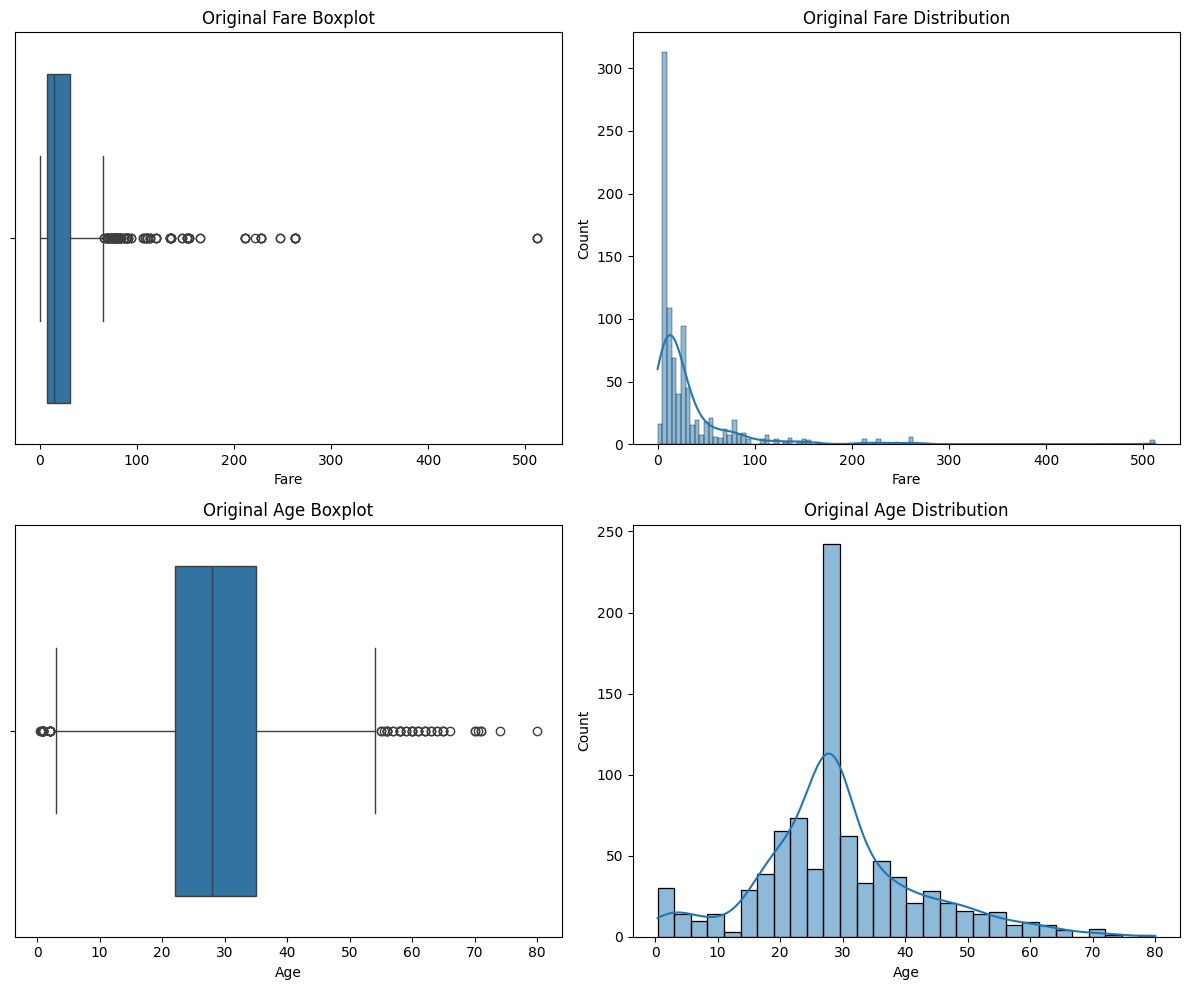

Age IQR bounds: 2.50 to 54.50


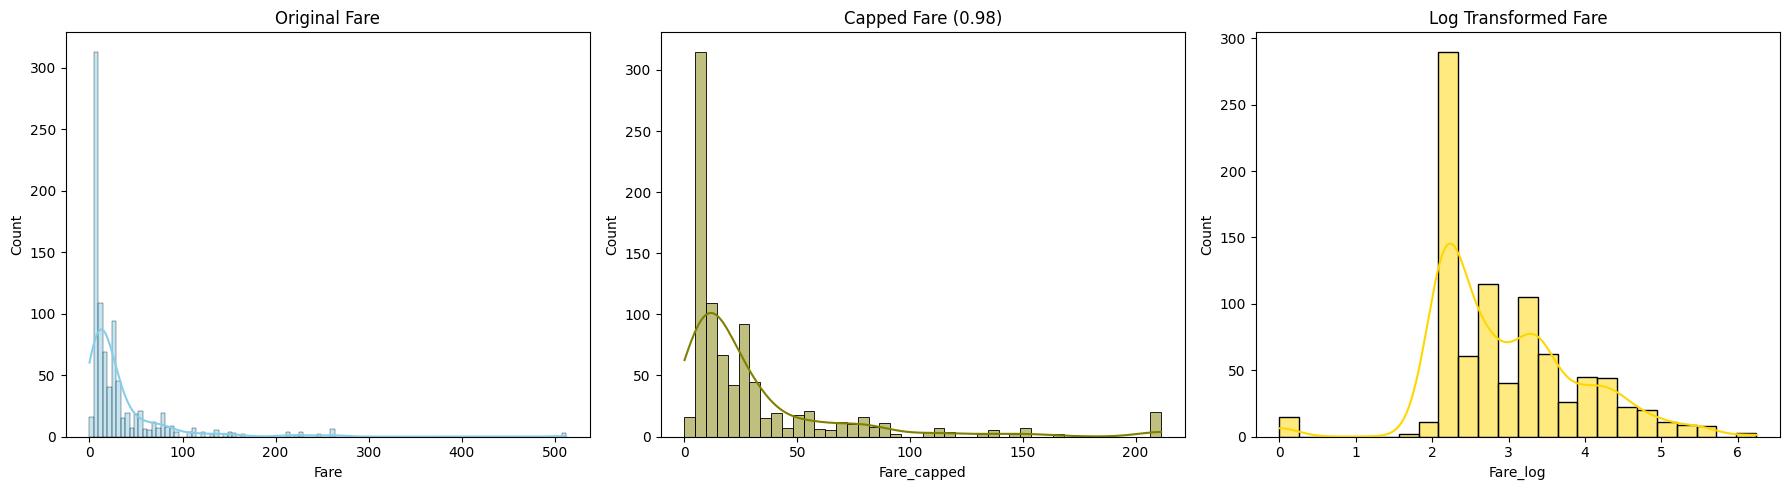

Summary of Outlier Treatment:
- Fare: Max original 512.33 -> Max capped 211.34
- Age: Max original 80.00 -> Max IQR capped 54.50


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Visualize original distributions from the encoded dataframe
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(x=titanic_df_encoded['Fare'], ax=axes[0, 0]).set_title('Original Fare Boxplot')
sns.histplot(titanic_df_encoded['Fare'], kde=True, ax=axes[0, 1]).set_title('Original Fare Distribution')
sns.boxplot(x=titanic_df_encoded['Age'], ax=axes[1, 0]).set_title('Original Age Boxplot')
sns.histplot(titanic_df_encoded['Age'], kde=True, ax=axes[1, 1]).set_title('Original Age Distribution')
plt.tight_layout()
plt.show()

# 2. Detect Outliers (IQR Method for Age)
Q1 = titanic_df_encoded['Age'].quantile(0.25)
Q3 = titanic_df_encoded['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Age IQR bounds: {lower_bound:.2f} to {upper_bound:.2f}")

# 3. Handle Outliers
# Create a consolidated cleaned dataframe
titanic_cleaned_outliers = titanic_df_encoded.copy()

# A. Quantile Capping (Fare at 0.98)
fare_98_quantile = titanic_df_encoded['Fare'].quantile(0.98)
titanic_cleaned_outliers['Fare_capped'] = titanic_df_encoded['Fare'].clip(upper=fare_98_quantile)

# B. Log Transformation (Fare)
titanic_cleaned_outliers['Fare_log'] = np.log1p(titanic_df_encoded['Fare'])

# C. Capping Age using IQR
titanic_cleaned_outliers['Age_capped'] = titanic_df_encoded['Age'].clip(lower_bound, upper_bound)

# 4. Compare results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(titanic_df_encoded['Fare'], kde=True, ax=axes[0], color='skyblue').set_title('Original Fare')
sns.histplot(titanic_cleaned_outliers['Fare_capped'], kde=True, ax=axes[1], color='olive').set_title('Capped Fare (0.98)')
sns.histplot(titanic_cleaned_outliers['Fare_log'], kde=True, ax=axes[2], color='gold').set_title('Log Transformed Fare')
plt.tight_layout()
plt.show()

print("Summary of Outlier Treatment:")
print(f"- Fare: Max original {titanic_df_encoded['Fare'].max():.2f} -> Max capped {titanic_cleaned_outliers['Fare_capped'].max():.2f}")
print(f"- Age: Max original {titanic_df_encoded['Age'].max():.2f} -> Max IQR capped {titanic_cleaned_outliers['Age_capped'].max():.2f}")

#Exercise 5

Summary of Scaled Features:


,Age_scaled,Fare_scaled,FamilySize_scaled
mean,4.395934e-17,0.474133,0.090664
std,1.000563e+00,0.155065,0.161470
min,-2.200161e+00,0.000000,0.000000
max,2.117044e+00,1.000000,1.000000


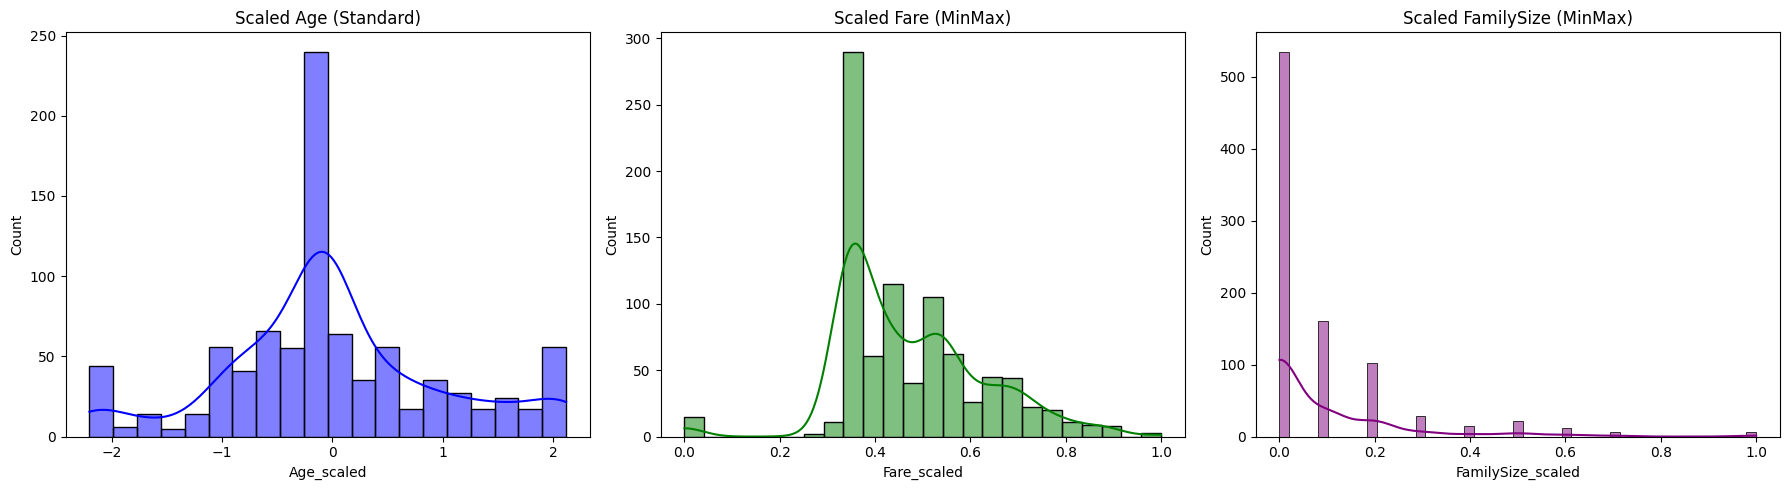

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Initialize the scalers
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

# Create a copy for the scaled dataset
titanic_scaled = titanic_cleaned_outliers.copy()

# 1. StandardScaler for 'Age_capped' (more normal distribution after clipping)
titanic_scaled['Age_scaled'] = std_scaler.fit_transform(titanic_scaled[['Age_capped']])

# 2. MinMaxScaler for 'Fare_log' (skewed/bounded) and 'FamilySize'
titanic_scaled['Fare_scaled'] = mm_scaler.fit_transform(titanic_scaled[['Fare_log']])
titanic_scaled['FamilySize_scaled'] = mm_scaler.fit_transform(titanic_scaled[['FamilySize']])

# Display the results of scaling
print("Summary of Scaled Features:")
display(titanic_scaled[['Age_scaled', 'Fare_scaled', 'FamilySize_scaled']].describe().loc[['mean', 'std', 'min', 'max']])

# Quick visualization of scaled features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(titanic_scaled['Age_scaled'], kde=True, ax=axes[0], color='blue').set_title('Scaled Age (Standard)')
sns.histplot(titanic_scaled['Fare_scaled'], kde=True, ax=axes[1], color='green').set_title('Scaled Fare (MinMax)')
sns.histplot(titanic_scaled['FamilySize_scaled'], kde=True, ax=axes[2], color='purple').set_title('Scaled FamilySize (MinMax)')
plt.tight_layout()
plt.show()

#Exercise 6

In [ ]:
# 1. Identify categorical columns
# Based on previous steps, these are the categorical variables
nominal_cols = ['Sex', 'Embarked', 'Pclass', 'Title']

# 2. Finalize One-Hot Encoding
# We use the version of the data that has been cleaned of missing values and outliers
# but before the final scaling results are merged.
titanic_final_encoded = pd.get_dummies(titanic_df_processed, columns=nominal_cols, drop_first=True)

# Note: titanic_scaled already contains many of these columns from previous steps.
# We will ensure the final dataset reflects the cleaned and encoded state.

print("Categorical encoding finalized.")
print(f"New columns added: {[col for col in titanic_final_encoded.columns if any(x in col for x in nominal_cols)]}")

# Display the head of the finalized encoded dataframe
titanic_final_encoded.head()

Categorical encoding finalized.
New columns added: ['Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3', 'Title_Carlo', 'Title_Cruyssen', 'Title_Gordon', 'Title_Impe', 'Title_Master', 'Title_Melkebeke', 'Title_Messemaeker', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Mulder', 'Title_Pelsmaeker', 'Title_Planke', 'Title_Rare', 'Title_Shawah', 'Title_Steen', 'Title_Velde', 'Title_Walle', 'Title_der', 'Title_the', 'Title_y']


,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,...,Title_Pelsmaeker,Title_Planke,Title_Rare,Title_Shawah,Title_Steen,Title_Velde,Title_Walle,Title_der,Title_the,Title_y
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Unknown,2,...,False,False,False,False,False,False,False,False,False,False
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,2,...,False,False,False,False,False,False,False,False,False,False
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Unknown,1,...,False,False,False,False,False,False,False,False,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,2,...,False,False,False,False,False,False,False,False,False,False
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Unknown,1,...,False,False,False,False,False,False,False,False,False,False


#Exercise 7

In [ ]:
# 1. Create Age Groups
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
titanic_cleaned_outliers['AgeGroup'] = pd.cut(titanic_cleaned_outliers['Age'], bins=bins, labels=labels)

# 2. One-hot encode Age Groups
titanic_age_encoded = pd.get_dummies(titanic_cleaned_outliers, columns=['AgeGroup'], prefix='AgeGroup', drop_first=True)

# 3. Final Consolidation
# We take scaled numericals, categorical dummies from previous step, and the new age group dummies
scaled_cols = ['Age_scaled', 'Fare_scaled', 'FamilySize_scaled', 'Survived']
encoded_cols = [col for col in titanic_final_encoded.columns if any(x in col for x in ['Sex_', 'Embarked_', 'Pclass_', 'Title_'])]
age_group_cols = [col for col in titanic_age_encoded.columns if 'AgeGroup_' in col]

titanic_model_ready = pd.concat([
    titanic_scaled[scaled_cols],
    titanic_final_encoded[encoded_cols],
    titanic_age_encoded[age_group_cols]
], axis=1)

print(f"Final Dataset Shape: {titanic_model_ready.shape}")
print("\nAge Group distributions:")
print(titanic_cleaned_outliers['AgeGroup'].value_counts())

print("\nFirst 5 rows of the model-ready dataset:")
display(titanic_model_ready.head())

# Check for any remaining non-numeric columns
non_numeric = titanic_model_ready.select_dtypes(exclude=[np.number, bool]).columns.tolist()
print("\nRemaining non-numeric columns:", non_numeric)

Final Dataset Shape: (889, 33)

Age Group distributions:
AgeGroup
Adult     729
Teen       70
Child      69
Senior     21
Name: count, dtype: int64

First 5 rows of the model-ready dataset:


,Age_scaled,Fare_scaled,FamilySize_scaled,Survived,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,Title_Carlo,...,Title_Shawah,Title_Steen,Title_Velde,Title_Walle,Title_der,Title_the,Title_y,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,-0.581209,0.338125,0.1,0,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
1,0.747162,0.685892,0.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,-0.249116,0.350727,0.0,1,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,0.498092,0.639463,0.1,1,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0.498092,0.352955,0.0,0,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False



Remaining non-numeric columns: []
